# 📉 CLV Decay Forecast — BG/NBD Forward Projection
**LushProtein Analytics | Medallion Architecture**

Extends the static BG/NBD P_Alive snapshot from `04_ds3-1_channel_heterogeneity` into a **forward-looking revenue decay curve**.

| Model | Output |
|---|---|
| BG/NBD (Beta-Geo/NBD) | Expected purchases per customer at t = 30 / 60 / 90 / 180 / 365 days |
| Gamma-Gamma | Expected AOV per customer (repeat-order value) |
| Combined | Expected revenue decay curve by channel (Analysis A) and SG/MY country (Analysis B) |

> **What this answers:** If we do nothing, how much revenue should we expect from the current customer base over the next 30 / 60 / 90 / 180 / 365 days — and which segments decay fastest?


## 0. Setup & Paths

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from lifetimes import BetaGeoFitter, GammaGammaFitter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

BASE_DIR   = Path('.')
GOLD_DIR   = BASE_DIR / 'medallion' / 'gold'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS_CHANNEL = {
    'DTC'            : '#3BB273',
    'Lazada'         : '#2E86AB',
    'Shopee'         : '#F97316',
    'Social Referral': '#E84855',
}
COLORS_COUNTRY = {'SG': '#2E86AB', 'MY': '#3BB273', 'Other': '#A8A8A8'}

HORIZONS       = [30, 60, 90, 180, 365]
HORIZON_LABELS = ['30d', '60d', '90d', '180d', '365d']
HORIZON_DAYS   = dict(zip(HORIZON_LABELS, HORIZONS))

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


---
## 1. Load & Prepare 'RFM' Data

In [17]:
# Load gold tables
co = pd.read_parquet(GOLD_DIR / 'gold_customer_orders.parquet')
cp = pd.read_parquet(GOLD_DIR / 'gold_customer_profiles.parquet')
da = pd.read_parquet(GOLD_DIR / 'gold_discount_analysis.parquet')
cf = pd.read_parquet(GOLD_DIR / 'gold_churn_features.parquet')

# ── Build exclusion sets (Matrixify, B2B/affiliate, guest-checkout) ───────────
matrixify_first = co[(co['order_sequence']==1) & (co['Source']=='matrixify app')]['customer_id']
order_counts = co[co['customer_id'].isin(matrixify_first)].groupby('customer_id')['order_id'].nunique()

single_order = set(order_counts[order_counts==1].index)
multi_ids = order_counts[order_counts>1].index
all_matrixify_multi = co[co['customer_id'].isin(multi_ids)].groupby('customer_id')['Source'].apply(lambda s: (s=='matrixify app').all())
multi_all = set(all_matrixify_multi[all_matrixify_multi].index)

matrixify_only   = single_order | multi_all                # 1,066 — no genuine activity
matrixify_active = set(matrixify_first) - matrixify_only   # 308 — genuine subsequent activity, unreliable first_order_date

b2b_affiliate  = set(da[da['is_b2b_or_affiliate']]['customer_id'])
guest_checkout = {'7888450879743'}

# ── Exclude B2B / affiliate / Matrixify / guest-checkout customers ────────────
# - is_b2b_or_affiliate: known B2B / high-AOV outlier accounts
# - guest-checkout placeholder: aggregates many real customers' guest orders under one customer_id
# - matrixify_only: entire order history is Matrixify-imported (no genuine activity)
# - matrixify_active: Matrixify-imported FIRST order, but genuine subsequent activity
#   (first_order_date reflects a migration timestamp, not a true first-purchase date —
#   unreliable for BG/NBD recency/tenure inputs)
b2b_customers = b2b_affiliate | guest_checkout | matrixify_only | matrixify_active

co_clean = co[~co['customer_id'].astype(str).isin({str(c) for c in b2b_customers})].copy()
co_paid  = co_clean[co_clean['payment_status'] == 'paid'].copy()
co_paid['processed_at']       = pd.to_datetime(co_paid['processed_at'], errors='coerce', utc=True)
co_paid['processed_at_naive'] = co_paid['processed_at'].dt.tz_localize(None)

# ── Channel classification (same rules as 04_ds3-1) ─────────────────────────
social_sources  = ['facebook', 'meta', 'ig', 'igshopping', 'tiktok', 'snowball', 'igpost', 'affiliate']
social_mediums  = ['paid_social', 'social', 'instagram_stories', 'referral_url', 'affiliate']
social_channels = ['TikTok', 'Affiliate']

first_orders = co_paid[co_paid['order_sequence'] == 1][[
    'customer_id', 'processed_at_naive', 'channel',
    'utm_source', 'utm_medium', 'price_total'
]].rename(columns={'processed_at_naive': 'first_order_date',
                   'price_total'        : 'first_order_spend'}).copy()

# Fill NaN utm fields before string operations
first_orders['utm_source'] = first_orders['utm_source'].fillna('')
first_orders['utm_medium'] = first_orders['utm_medium'].fillna('')

is_social = (
    first_orders['channel'].isin(social_channels) |
    first_orders['utm_source'].str.lower().isin(social_sources) |
    first_orders['utm_medium'].str.lower().isin(social_mediums)
)
first_orders['acquisition_channel'] = np.where(
    is_social, 'Social Referral', first_orders['channel'])

TARGET_CHANNELS = ['DTC', 'Lazada', 'Shopee', 'Social Referral']
first_orders = first_orders[
    first_orders['acquisition_channel'].isin(TARGET_CHANNELS)].copy()

# ── Add country from gold_customer_profiles ──────────────────────────────────
def map_country(c):
    if pd.isna(c): return 'Other'
    c = str(c).upper().strip()
    if c in ('SG', 'SGP'): return 'SG'
    if c in ('MY', 'MYS'): return 'MY'
    return 'Other'

cp_country = cp[['customer_id', 'acquisition_country']].copy()
cp_country['country'] = cp_country['acquisition_country'].apply(map_country)
first_orders = first_orders.merge(
    cp_country[['customer_id', 'country']], on='customer_id', how='left')
first_orders['country'] = first_orders['country'].fillna('Other')

# ── Build RFM table ──────────────────────────────────────────────────────────
co_model = co_paid[
    co_paid['customer_id'].isin(first_orders['customer_id'])].copy()
obs_date = co_model['processed_at_naive'].max()

rfm = co_model.groupby('customer_id').agg(
    last_order_date=('processed_at_naive', 'max'),
    AOF            =('order_id', lambda x: len(x) - 1),  # frequency = total orders - 1 (excludes the conditioning first order, per BG/NBD convention)
    total_spend    =('price_total', 'sum'),
).reset_index()

rfm = rfm.merge(
    first_orders[['customer_id', 'first_order_date', 'first_order_spend',
                  'acquisition_channel', 'country']],
    on='customer_id', how='inner')

rfm['recency_days'] = (
    rfm['last_order_date'] - rfm['first_order_date']).dt.days
rfm['tenure_days']  = (
    obs_date - rfm['first_order_date']).dt.days
rfm['repeat_spend'] = rfm['total_spend'] - rfm['first_order_spend']
rfm['AOV']          = np.where(
    rfm['AOF'] > 0, rfm['repeat_spend'] / rfm['AOF'], 0)

# ── Issue 1: Validate BG/NBD input constraints ───────────────────────────────
assert (rfm['recency_days'] >= 0).all(), \
    'Negative recency found — check timezone stripping'
assert (rfm['recency_days'] <= rfm['tenure_days']).all(), \
    'Recency exceeds tenure — possible timezone stripping inconsistency'
n_before = len(rfm)
rfm = rfm[rfm['tenure_days'] > 0].copy()
print(f'Dropped {n_before - len(rfm)} zero-tenure customers '
      f'(first order = observation date; uninformative for BG/NBD)')
print('✅ BG/NBD input validation passed (recency ≤ tenure for all rows)')

print(f'\nModel dataset  : {len(rfm):,} customers')
print(f'Observation date: {obs_date.date()}')
rfm['gap'] = rfm['tenure_days'] - rfm['recency_days']

print(f'\nChannel breakdown:')
print(rfm['acquisition_channel'].value_counts().to_string())
print(f'\nCountry breakdown:')
print(rfm['country'].value_counts().to_string())

Dropped 21 zero-tenure customers (first order = observation date; uninformative for BG/NBD)
✅ BG/NBD input validation passed (recency ≤ tenure for all rows)

Model dataset  : 9,900 customers
Observation date: 2026-03-31

Channel breakdown:
acquisition_channel
DTC                4829
Lazada             3654
Social Referral     744
Shopee              673

Country breakdown:
country
MY       4788
SG       4462
Other     650


In [18]:
# ── Data Quality Reconciliation: exclusion set sizes & overlaps ───────────────
print(f'1. Total identifiable customers: {co["customer_id"].nunique():,}')
print(f'   Orders with null customer_id: {co["customer_id"].isna().sum()}')

print(f'2. gold_churn_features customers: {cf["customer_id"].nunique():,}')

print(f'3. Matrixify-only (no genuine activity): {len(matrixify_only):,}')
print(f'   Matrixify-first-but-active: {len(matrixify_active):,}')

print(f'4. is_b2b_or_affiliate: {len(b2b_affiliate):,}')
print(f'   Guest-checkout placeholder: {len(guest_checkout)}')

print(f'\n5. Overlap checks:')
print(f'   is_b2b_or_affiliate ∩ Matrixify-only: {len(b2b_affiliate & matrixify_only)}')
print(f'   is_b2b_or_affiliate ∩ Matrixify-active: {len(b2b_affiliate & matrixify_active)}')
print(f'   is_b2b_or_affiliate ∩ guest-checkout: {len(b2b_affiliate & guest_checkout)}')
print(f'   Matrixify-active ∩ guest-checkout: {len(matrixify_active & guest_checkout)}')

print(f'\n6. Total excluded (union): {len(b2b_customers):,}')
print(f'   Model population (13,885 minus union): {co["customer_id"].nunique() - len(b2b_customers):,}')

1. Total identifiable customers: 13,885
   Orders with null customer_id: 153
2. gold_churn_features customers: 12,819
3. Matrixify-only (no genuine activity): 1,066
   Matrixify-first-but-active: 308
4. is_b2b_or_affiliate: 208
   Guest-checkout placeholder: 1

5. Overlap checks:
   is_b2b_or_affiliate ∩ Matrixify-only: 16
   is_b2b_or_affiliate ∩ Matrixify-active: 9
   is_b2b_or_affiliate ∩ guest-checkout: 0
   Matrixify-active ∩ guest-checkout: 0

6. Total excluded (union): 1,558
   Model population (13,885 minus union): 12,327


## Data Quality Note: Reconciling Customer Base Counts Across Gold Tables

This CLV/BG-NBD analysis required reconciling customer counts across multiple gold tables, as different tables apply different and partially-overlapping exclusion criteria. The reconciliation, verified at the individual customer ID level, is as follows:

**1. Total identifiable customers: 13,885** — unique, non-null `customer_id` values in `gold_customer_orders`. There are **153 orders which have `customer_id = NaN`** (mostly 2022 Malaysia Matrixify-imported legacy records with order names like `#LPMY1038`-`#LPMY1066`, plus a handful of POS walk-in sales and unassigned Draft Orders), are excluded from customer-level analyses.

**2. `gold_churn_features`: 12,819 customers** — excludes **1,066 customers** whose entire order history consists solely of `Source == 'matrixify app'` records (verified at the ID level).

**3. Matrixify-imported first orders: 1,374 customers** (across all orders, paid + unpaid), splitting into:
   - **1,066**: Matrixify is the *only* source across their entire order history — no genuine Shopify-native activity (matches #2 exactly)
   - **308**: Matrixify-imported first order, but with genuine subsequent (non-imported) activity — `first_order_date` reflects a migration timestamp, not a true first-purchase date, despite the customer having real engagement. These 308 customers can be included in order-level analyses but not in BG/NBD and Gamma gamma models as recency information is required. \

**4. `is_b2b_or_affiliate` flag: 208 customers** (from `gold_discount_analysis`) — identifies B2B/affiliate accounts via discount codes and order tags. This **overlaps with the Matrixify exclusions**: 16 customers are both Matrixify-only and B2B/affiliate-flagged, and 9 are both Matrixify-active and B2B/affiliate-flagged (25 total overlap, confirmed via order-tag inspection showing "B2B" and "affiliates" tags within Matrixify-imported orders).

**5. Guest-checkout placeholder: 1 customer** (`7888450879743`) — a Shopify guest-checkout aggregation artifact (666 orders, all 2025, representing many distinct real customers under one ID). No overlap with any other exclusion set.

---

**Deriving the final model population (12,327):**

| Step | Customers |
|---|---|
| Total identifiable customers | 13,885 |
| − Matrixify-only (1,066) | |
| − Matrixify-first-but-active (308) | |
| − `is_b2b_or_affiliate` (208) | |
| − Guest-checkout placeholder (1) | |
| **− Overlaps (-25)*** | |
| **= Union of all exclusions** | **1,558** |
| **= Model population (13,885 − 1,558)** | **12,327** |

*\*The four exclusion criteria are not mutually exclusive — 25 customers fall into more than one category (16 Matrixify-only ∩ B2B/affiliate, 9 Matrixify-active ∩ B2B/affiliate). A naive sum (`1,066 + 308 + 208 + 1 = 1,583`) would double-count these 25 customers. The correct exclusion count is the **union** of all four sets (`1,558`), computed directly via set operations to avoid double-counting.*

**Implication for this notebook**: the 308 Matrixify-first-but-active customers are retained in `gold_churn_features`'s 12,819 (appropriate for revenue/category-level analyses), but their unreliable `first_order_date` makes them unsuitable for BG/NBD's recency/tenure inputs. This notebook's model population therefore excludes Matrixify-first-order customers (both subsets, 1,374 total before overlap correction), `is_b2b_or_affiliate`-flagged customers (208), and the guest-checkout placeholder (1) — yielding **12,327** customers as the reconciled starting population, before the channel-scoping (`TARGET_CHANNELS`) and zero-tenure filters described in subsequent steps.

## Population Scoping: Acquisition Cohort vs. Activity Status

Before fitting BG/NBD, the model population (9,900 customers across DTC/Lazada/Shopee/Social Referral) was checked for **temporal coherence**, since BG/NBD assumes a single stationary population.

**Finding**: Lazada is overwhelmingly a 2020-2022 legacy channel — 3,615 of 3,654 Lazada customers (99%) were acquired in 2020-2022, with **zero acquisitions in 2023-2025**. These customers show a median `tenure - recency` gap of ~1,633 days (~4.5 years) — i.e., the typical Lazada customer hasn't ordered in over four years. Including this dormant cohort alongside actively-growing 2023+ cohorts (DTC, Shopee, Social Referral) violates BG/NBD's stationarity assumption and risks distorting the global `(r, alpha, a, b)` parameter estimates.

**Three scoping options were considered**:

1. **Acquisition-date cutoff (`first_order_date >= 2023`)**: cleanly removes the dormant Lazada cohort, but also discards **6,256 pre-2023-acquired customers overall** (not just Lazada) — including **195 customers (97 DTC, 98 Lazada) who are still active** (ordered within the last year) despite their early acquisition date. These long-tenured, currently-active customers are prime candidates for the highest-value "Loyal/Active" segment, and excluding them understates that segment.

2. **Recency cutoff (`gap <= 365`, applied to all customers)**: would retain the 195 customers above, but **also removes 749 of the 3,644 customers who were acquired in 2023+ but have already gone quiet (`gap > 365`)**. These "at-risk"/"lapsed" customers are exactly what `P_Alive` is designed to assess — removing them creates survivorship bias, where the remaining population looks artificially healthy.

3. **Combined rule (adopted)**: exclude a customer only if they are **both** pre-2023-acquired **and** dormant (`gap > 365`). This removes the 6,061 "ancient and dormant" customers (the genuine stationarity problem — mostly Lazada, plus ~2,542 dormant pre-2023 DTC customers), while retaining the 749 "recent but already quiet" customers (no survivorship bias) and adding back the 195 "long-tenured but still active" customers.

**Net result**: final model population = **3,839 customers** (3,644 + 195).

---

**Separate scope note**: `TARGET_CHANNELS` (DTC, Lazada, Shopee, Social Referral) itself excludes ~18% of paid customers whose first order's channel was Marketplace (n=1,189, unresolved — no UTM data, ~43%/57% SG/MY split), Draft Order (n=528, manual/admin orders), POS (n=365, in-person sales), or Email (n=130). Draft Order and POS lack any acquisition-channel signal by construction (no website session = no UTM); Marketplace remains an open question for future investigation. These customers are out of scope for this CLV model.

In [19]:
# ── Supporting data for population-scoping decision ───────────────────────────────────────────
print('Acquisition year by channel:')
print(pd.crosstab(rfm['acquisition_channel'], rfm['first_order_date'].dt.year))

pre_2023 = rfm['first_order_date'] < '2023-01-01'
dormant  = rfm['gap'] > 365

print(f'\nPre-2023-acquired: {pre_2023.sum():,}')
print(f'  - dormant (gap>365): {(pre_2023 & dormant).sum():,}')
print(f'  - still active (gap<=365): {(pre_2023 & ~dormant).sum():,}')

print(f'\n2023+-acquired: {(~pre_2023).sum():,}')
print(f'  - already dormant (gap>365): {(~pre_2023 & dormant).sum():,}')
print(f'  - still active (gap<=365): {(~pre_2023 & ~dormant).sum():,}')

Acquisition year by channel:
first_order_date     2019  2020  2021  2022  2023  2024  2025  2026
acquisition_channel                                                
DTC                     1   796  1274   568   170   460  1296   264
Lazada                  0   896  2055   664     0     0     0    39
Shopee                  0     0     0     0     0     0   392   281
Social Referral         0     0     0     2     9   101   430   202

Pre-2023-acquired: 6,256
  - dormant (gap>365): 6,061
  - still active (gap<=365): 195

2023+-acquired: 3,644
  - already dormant (gap>365): 749
  - still active (gap<=365): 2,895


In [20]:
# ── Apply combined scoping rule: exclude pre-2023-acquired AND dormant customers ──
n_before_scope = len(rfm)
exclude_mask = (rfm['first_order_date'] < '2023-01-01') & (rfm['gap'] > 365)
rfm = rfm[~exclude_mask].copy()
print(f'Final model population: {n_before_scope:,} → {len(rfm):,} customers')

print(f'\nChannel breakdown (final population):')
print(rfm['acquisition_channel'].value_counts().to_string())
print(f'\nCountry breakdown (final population):')
print(rfm['country'].value_counts().to_string())

Final model population: 9,900 → 3,839 customers

Channel breakdown (final population):
acquisition_channel
DTC                2287
Social Referral     742
Shopee              673
Lazada              137

Country breakdown (final population):
country
SG       2110
MY       1468
Other     261


---
## 2. Fit BG/NBD & Gamma-Gamma Models

In [21]:
# ── BG/NBD ──────────────────────────────────────────────────────────────────
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])

print('BG/NBD fitted.')
print(f'  r     = {bgf.params_["r"]:.4f}')
print(f'  alpha = {bgf.params_["alpha"]:.4f}')
print(f'  a     = {bgf.params_["a"]:.4f}')
print(f'  b     = {bgf.params_["b"]:.4f}')

# ── Gamma-Gamma ──────────────────────────────────────────────────────────────
gg_df = rfm[(rfm['AOF'] > 0) & (rfm['AOV'] > 0)].copy()

# Issue 3: Independence check — GG assumes no correlation between AOF and AOV
gg_corr = gg_df[['AOF', 'AOV']].corr().loc['AOF', 'AOV']
print(f'\nGamma-Gamma independence check (AOF vs AOV):')
print(f'  Pearson r = {gg_corr:.4f}')
if abs(gg_corr) > 0.1:
    print(f'  ⚠️  |r| > 0.1 — independence assumption is weakly violated;'
          f' GG estimates carry additional uncertainty')
else:
    print(f'  ✅ |r| ≤ 0.1 — independence assumption holds')

ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(gg_df['AOF'], gg_df['AOV'])

print(f'\nGamma-Gamma fitted (on {len(gg_df):,} repeat buyers).')
print(f'  p = {ggf.params_["p"]:.4f}')
print(f'  q = {ggf.params_["q"]:.4f}')
print(f'  v = {ggf.params_["v"]:.4f}')

# Expected AOV for all customers
rfm['expected_aov'] = ggf.conditional_expected_average_profit(
    rfm['AOF'], rfm['AOV'])
rfm['p_alive'] = bgf.conditional_probability_alive(
    rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])

print(f'\nCurrent P_Alive (mean): {rfm["p_alive"].mean():.3f}')
print(f'Current P_Alive by channel:')
print(rfm.groupby('acquisition_channel')['p_alive']
        .agg(['mean', 'median']).round(3).to_string())

BG/NBD fitted.
  r     = 0.2248
  alpha = 62.6595
  a     = 0.3047
  b     = 0.8866

Gamma-Gamma independence check (AOF vs AOV):
  Pearson r = 0.2154
  ⚠️  |r| > 0.1 — independence assumption is weakly violated; GG estimates carry additional uncertainty

Gamma-Gamma fitted (on 1,025 repeat buyers).
  p = 2.5905
  q = 3.7003
  v = 94.9013

Current P_Alive (mean): 0.882
Current P_Alive by channel:
                     mean  median
acquisition_channel              
DTC                  0.86    1.00
Lazada               0.88    0.93
Shopee               0.93    1.00
Social Referral      0.90    1.00


In [22]:
# ── Customer segmentation: P_Alive × expected future value ────────────────────
rfm['p_alive'] = bgf.conditional_probability_alive(rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])
rfm['exp_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(90, rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])
rfm['exp_aov'] = ggf.conditional_expected_average_profit(rfm['AOF'], rfm['AOV'])
rfm['exp_revenue_90d'] = rfm['exp_purchases_90d'] * rfm['exp_aov']

# Simple segmentation
rfm['segment'] = pd.cut(rfm['p_alive'], bins=[0, 0.3, 0.6, 1.0], labels=['Likely Lost', 'At Risk', 'Champions'])

print(rfm.groupby('segment').agg(
    n_customers=('customer_id', 'count'),
    avg_p_alive=('p_alive', 'mean'),
    total_exp_revenue_90d=('exp_revenue_90d', 'sum'),
))

             n_customers  avg_p_alive  total_exp_revenue_90d
segment                                                     
Likely Lost          176         0.18                 674.52
At Risk              354         0.45               5,610.36
Champions           3309         0.97              52,117.62


In [23]:
# ── Check: is "Champions" dominated by AOF=0 (new, unproven) customers? ───────
print(rfm.groupby('segment')['AOF'].describe())

               count  mean  std  min  25%  50%  75%   max
segment                                                  
Likely Lost   176.00  2.43 3.98 1.00 1.00 1.00 2.00 46.00
At Risk       354.00  1.81 3.00 1.00 1.00 1.00 2.00 30.00
Champions   3,309.00  0.79 3.08 0.00 0.00 0.00 0.00 69.00


In [24]:
# ── Refined segmentation: P_Alive × AOF ────────────────────────────────────────
def segment_customer(row):
    if row['AOF'] == 0:
        return 'New / Unproven'
    elif row['p_alive'] >= 0.6:
        return 'Loyal / Active'
    elif row['p_alive'] >= 0.3:
        return 'At Risk'
    else:
        return 'Lapsed / Lost'

rfm['segment_v2'] = rfm.apply(segment_customer, axis=1)

print(rfm.groupby('segment_v2').agg(
    n_customers=('customer_id', 'count'),
    avg_p_alive=('p_alive', 'mean'),
    avg_AOF=('AOF', 'mean'),
    total_exp_revenue_90d=('exp_revenue_90d', 'sum'),
).assign(
    pct_customers=lambda d: d['n_customers']/d['n_customers'].sum(),
    pct_revenue=lambda d: d['total_exp_revenue_90d']/d['total_exp_revenue_90d'].sum(),
))

# ── Identify "lapsed VIPs": high-AOF customers now at-risk or lapsed ──────────
lapsed_vips = rfm[
    (rfm['AOF'] >= 5) & (rfm['p_alive'] < 0.6)
].sort_values('AOF', ascending=False)

print(f'\nLapsed VIPs (AOF>=5, P_Alive<0.6): {len(lapsed_vips)} customers')
print(lapsed_vips[['customer_id', 'AOF', 'AOV', 'p_alive', 'total_spend', 'acquisition_channel']].head(10))

                n_customers  avg_p_alive  avg_AOF  total_exp_revenue_90d  \
segment_v2                                                                 
At Risk                 354         0.45     1.81               5,610.36   
Lapsed / Lost           176         0.18     2.43                 674.52   
Loyal / Active          547         0.79     4.76              28,862.49   
New / Unproven         2762         1.00     0.00              23,255.13   

                pct_customers  pct_revenue  
segment_v2                                  
At Risk                  0.09         0.10  
Lapsed / Lost            0.05         0.01  
Loyal / Active           0.14         0.49  
New / Unproven           0.72         0.40  

Lapsed VIPs (AOF>=5, P_Alive<0.6): 30 customers
        customer_id  AOF    AOV  p_alive  total_spend acquisition_channel
3737  7755932958975   46 143.04     0.00     6,671.25              Lazada
1812  6347948392703   30 119.95     0.44     3,735.39              Lazada
41

## BG/NBD & Gamma-Gamma: Results, Segmentation, and Key Findings

**Model fit** (on the final 3,839-customer population, after the combined cohort/recency scoping):

- **BG/NBD**: `r=0.2248, alpha=62.6595, a=0.3047, b=0.8866`. The implied average dropout probability per transaction (`a/(a+b)`) is **~25.6%** — i.e., roughly 1-in-4 chance a customer "retires" after any given purchase, for a population-average customer.
- **Gamma-Gamma**: `p=2.5905, q=3.7003, v=94.9013`, fitted on 1,025 repeat buyers. Implied average transaction value (`p·v/(q-1)`) ≈ **SGD 91** — broadly consistent with the AOV ranges seen in the geographic analysis (SGD 70-110).
- **Caveat**: the Gamma-Gamma independence check shows a **weak violation** (Pearson r=0.2154, slightly above the 0.1 threshold): customers who order **more frequently (higher AOF)** also tend to **spend somewhat more per order (higher AOV)**, rather than frequency and order value being unrelated — driven by a small number of very-high-AOF customers (see below). **For the business, this means the model's average-spend-per-order estimates may slightly *understate* the value of the most frequent repeat customers** (e.g., the Loyal/Active segment) — so revenue projections for these high-frequency customers should be treated as a **conservative floor** rather than a precise figure, while the overall ~SGD 91 average transaction value remains a reasonable benchmark for the broader population.
- **Current P_Alive (mean): 0.882** — DTC 0.86, Lazada 0.88, Shopee 0.93, Social Referral 0.90.

**Customer segmentation** (`P_Alive` × `AOF`, n=3,839, total expected 90-day revenue ≈ SGD 58,403):

**How the SGD 58,403 figure is derived**: for each customer, `exp_purchases_90d = bgf.conditional_expected_number_of_purchases_up_to_time(90, AOF, recency_days, tenure_days)` gives the expected number of purchases in the next 90 days (already accounting for `P_Alive`), and `exp_aov = ggf.conditional_expected_average_profit(AOF, AOV)` gives the expected average transaction value. Multiplying these gives `exp_revenue_90d` per customer; summing `rfm['exp_revenue_90d']` across all 3,839 customers gives SGD 58,403.

| Segment | n (%) | Avg P_Alive | Avg AOF | Exp. Revenue (90d, %) | Per-Customer |
|---|---|---|---|---|---|
| Loyal / Active | 547 (14%) | 0.79 | 4.76 | SGD 28,862 (49%) | SGD 52.76 |
| At Risk | 354 (9%) | 0.45 | 1.81 | SGD 5,610 (10%) | SGD 15.85 |
| New / Unproven | 2,762 (72%) | 1.00 | 0.00 | SGD 23,255 (40%) | SGD 8.42 |
| Lapsed / Lost | 176 (5%) | 0.18 | 2.43 | SGD 675 (1%) | SGD 3.83 |

**Loyal/Active customers (14% of the base) drive nearly half of expected near-term revenue** — the highest-leverage segment for retention investment.

**Note on absolute figures**: total expected revenue nearly doubled relative to the earlier 3,644-customer fit (SGD 30,631 → 58,403). This reflects how sensitive BG/NBD's *population-level* parameters are to the inclusion of long-tenure "survivor" customers — adding 195 customers shifted the global dropout-probability estimate substantially, which re-weighted `P_Alive` for the entire population. **Relative segment comparisons (which customers are at-risk, which segments matter most) are more robust than the absolute revenue totals**, which should be treated as directional.

**Key finding — "Lazada Lapsed VIPs"**: among customers with `AOF≥5` and `P_Alive<0.6` (n=30), the highest-value entries are labeled `acquisition_channel="Lazada"` despite Lazada having zero 2023-2025 *acquisitions* — these customers were acquired via Lazada Malaysia in 2020-2022 but **continued ordering for 2+ years afterward** (one customer: AOF=46, total spend SGD 6,671, ordering roughly every 3 weeks from late 2021 through late 2024). A spot-check confirmed these orders are genuine, distinct, chronologically-spaced transactions (not a migration-batch artifact) — their `Source='matrixify app'` tag reflects an **ongoing Lazada-Shopify sync mechanism**, not a one-time historical import. Their `P_Alive≈0.00` despite `gap≤365` reflects a **real deviation from their established ~3-week purchase cadence** — these are validated, high-confidence win-back targets, well-suited to personalized (rather than automated) outreach given their documented purchase history and spend.

**Methodological note on the forward-projection survival proxy**: the channel/country decay charts use `p_active_t = 1 - exp(-exp_purchases_t)` — the probability of *at least one purchase* occurring within the next `t` days, under a Poisson approximation. This is a **different metric from `P_Alive`** (which estimates whether a customer has *permanently dropped out* by a given point) — it answers "will this customer transact at all in this window," not "has this customer churned." The two are not directly interchangeable, and `p_active_t` should be read as a **directional engagement-likelihood indicator** for the decay curves, not as a projected `P_Alive`.

---
## 3. Forward Projection at 30 / 60 / 90 / 180 / 365 Days

In [25]:
# For each horizon t, compute per-customer expected purchases and expected revenue
for t, label in zip(HORIZONS, HORIZON_LABELS):
    rfm[f'exp_purchases_{label}'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        t, rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])
    rfm[f'exp_revenue_{label}'] = rfm[f'exp_purchases_{label}'] * rfm['expected_aov']
    # Survival proxy: P(at least 1 purchase in next t days) ≈ 1 - exp(-E[X(t)])
    rfm[f'p_active_{label}'] = 1 - np.exp(-rfm[f'exp_purchases_{label}'])

print('Forward projections computed.')
print('\nAggregate summary — all channels combined:')
rows = []
for t, label in zip(HORIZONS, HORIZON_LABELS):
    total_rev = rfm[f'exp_revenue_{label}'].sum()
    pct_active = rfm[f'p_active_{label}'].mean()
    monthly_rate = total_rev / t * 30
    rows.append({'Horizon': label, 'Expected Revenue (SGD)': total_rev,
                 'Monthly Rate (SGD)': monthly_rate,
                 '% Likely to Transact': pct_active})
agg = pd.DataFrame(rows).set_index('Horizon')
agg['Expected Revenue (SGD)'] = agg['Expected Revenue (SGD)'].apply(lambda x: f'{x:,.0f}')
agg['Monthly Rate (SGD)']     = agg['Monthly Rate (SGD)'].apply(lambda x: f'{x:,.0f}')
agg['% Likely to Transact']   = agg['% Likely to Transact'].apply(lambda x: f'{x:.1%}')
display(agg)

Forward projections computed.

Aggregate summary — all channels combined:


,Expected Revenue (SGD),Monthly Rate (SGD),% Likely to Transact
Horizon,,,
30d,"20,147","20,147",5.3%
60d,"39,567","19,784",9.7%
90d,"58,402","19,467",13.4%
180d,"112,210","18,702",22.3%
365d,"214,060","17,594",34.6%


---
## 4A. Channel Decay — Customer Survival & Revenue

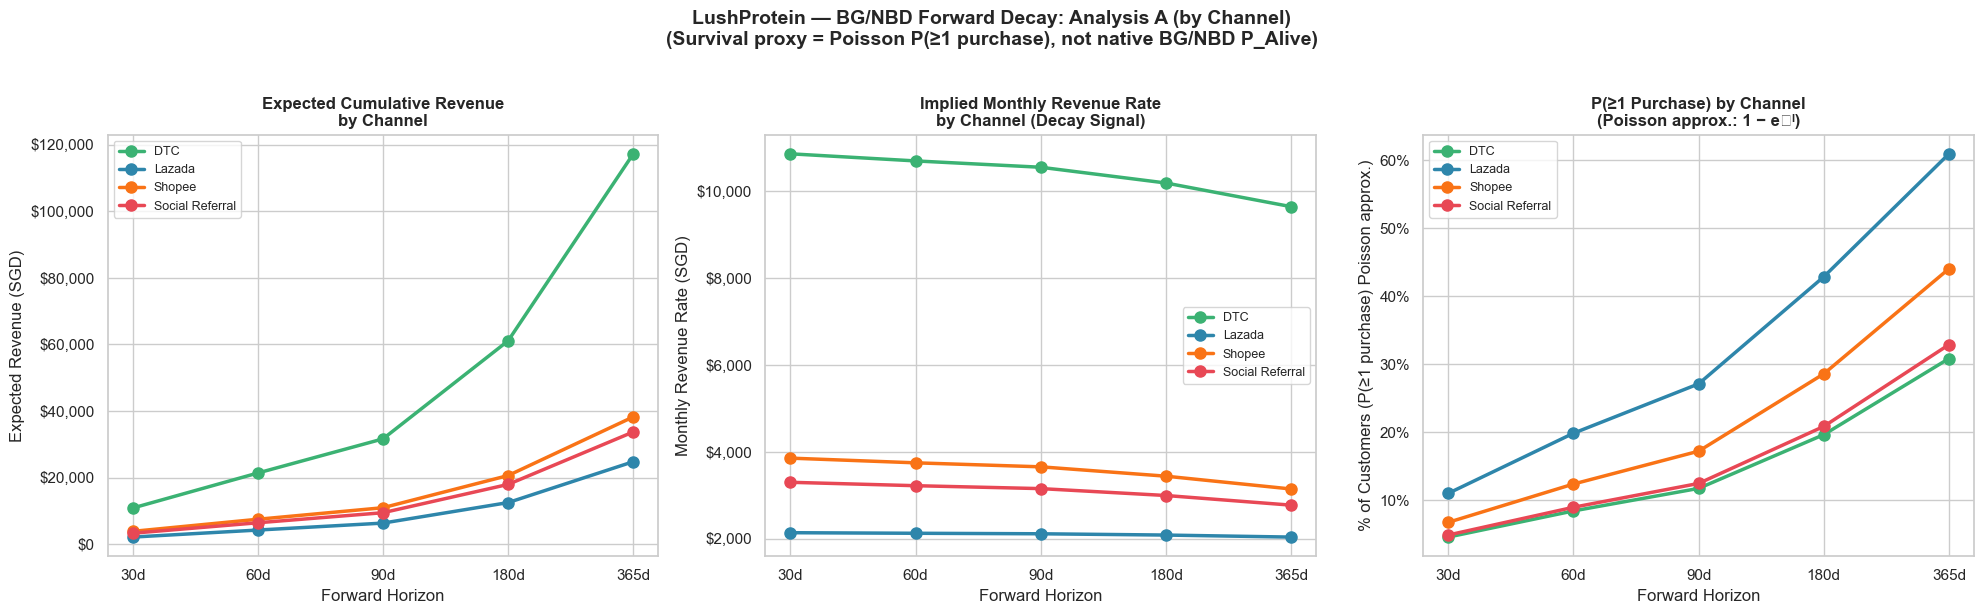

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel 1: Expected cumulative revenue by channel ──────────────────────────
ax1 = axes[0]
for ch, color in COLORS_CHANNEL.items():
    sub = rfm[rfm['acquisition_channel'] == ch]
    revenues = [sub[f'exp_revenue_{lbl}'].sum() for lbl in HORIZON_LABELS]
    ax1.plot(HORIZON_LABELS, revenues, marker='o', linewidth=2.5,
             markersize=8, label=ch, color=color)
ax1.set_title('Expected Cumulative Revenue\nby Channel', fontsize=12, fontweight='bold')
ax1.set_xlabel('Forward Horizon')
ax1.set_ylabel('Expected Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)

# ── Panel 2: Monthly revenue run rate by channel (decay signal) ──────────────
ax2 = axes[1]
for ch, color in COLORS_CHANNEL.items():
    sub = rfm[rfm['acquisition_channel'] == ch]
    rates = [sub[f'exp_revenue_{lbl}'].sum() / HORIZON_DAYS[lbl] * 30
             for lbl in HORIZON_LABELS]
    ax2.plot(HORIZON_LABELS, rates, marker='o', linewidth=2.5,
             markersize=8, label=ch, color=color)
ax2.set_title('Implied Monthly Revenue Rate\nby Channel (Decay Signal)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Forward Horizon')
ax2.set_ylabel('Monthly Revenue Rate (SGD)')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9)

# ── Panel 3: Survival curve — % customers expected to transact by channel ─────
ax3 = axes[2]
for ch, color in COLORS_CHANNEL.items():
    sub = rfm[rfm['acquisition_channel'] == ch]
    pct = [sub[f'p_active_{lbl}'].mean() * 100 for lbl in HORIZON_LABELS]
    ax3.plot(HORIZON_LABELS, pct, marker='o', linewidth=2.5,
             markersize=8, label=ch, color=color)
ax3.set_title('P(≥1 Purchase) by Channel\n(Poisson approx.: 1 − e⁻ˡ)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Forward Horizon')
ax3.set_ylabel('% of Customers (P(≥1 purchase) Poisson approx.)')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend(fontsize=9)

plt.suptitle('LushProtein — BG/NBD Forward Decay: Analysis A (by Channel)\n'
             '(Survival proxy = Poisson P(≥1 purchase), not native BG/NBD P_Alive)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clv_decay_channel.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Channel decay summary table
print('=== Channel Decay Summary ===')
rows = []
for ch in TARGET_CHANNELS:
    sub = rfm[rfm['acquisition_channel'] == ch]
    row = {'Channel': ch, 'Customers': len(sub)}
    for lbl in HORIZON_LABELS:
        row[f'Rev {lbl} (SGD)'] = sub[f'exp_revenue_{lbl}'].sum()
        row[f'Alive {lbl}'] = sub[f'p_active_{lbl}'].mean()
    rows.append(row)
summary_ch = pd.DataFrame(rows).set_index('Channel')
display(summary_ch)

# Monthly rate decay: ratio of 365d monthly rate vs 30d monthly rate
for ch in TARGET_CHANNELS:
    sub = rfm[rfm['acquisition_channel'] == ch]
    rate_30  = sub['exp_revenue_30d'].sum()  # 30-day cumulative total == 30-day monthly rate (30 days ~ 1 month, no scaling needed)
    rate_365 = sub['exp_revenue_365d'].sum() / 365 * 30
    decay_pct = (rate_30 - rate_365) / rate_30 * 100 if rate_30 > 0 else 0
    print(f'{ch:20s}: 30d monthly rate SGD {rate_30:>10,.0f} → 365d rate SGD {rate_365:>10,.0f}  '
          f'(decay {decay_pct:.1f}%)')

=== Channel Decay Summary ===


,Customers,Rev 30d (SGD),Alive 30d,Rev 60d (SGD),Alive 60d,Rev 90d (SGD),Alive 90d,Rev 180d (SGD),Alive 180d,Rev 365d (SGD),Alive 365d
Channel,,,,,,,,,,,
DTC,2287,"10,856.32",0.05,"21,384.96",0.08,"31,640.82",0.12,"61,107.29",0.20,"117,286.16",0.31
Lazada,137,"2,138.40",0.11,"4,250.54",0.20,"6,340.80",0.27,"12,505.02",0.43,"24,789.78",0.61
Shopee,673,"3,854.14",0.07,"7,492.22",0.12,"10,962.40",0.17,"20,632.20",0.29,"38,253.34",0.44
Social Referral,742,"3,298.25",0.05,"6,439.73",0.09,"9,458.47",0.12,"17,965.12",0.21,"33,730.70",0.33


DTC                 : 30d monthly rate SGD     10,856 → 365d rate SGD      9,640  (decay 11.2%)
Lazada              : 30d monthly rate SGD      2,138 → 365d rate SGD      2,038  (decay 4.7%)
Shopee              : 30d monthly rate SGD      3,854 → 365d rate SGD      3,144  (decay 18.4%)
Social Referral     : 30d monthly rate SGD      3,298 → 365d rate SGD      2,772  (decay 15.9%)


In [31]:
# ── 1. Segment composition: Shopee vs other channels ──────────────────────────
print(pd.crosstab(rfm['acquisition_channel'], rfm['segment_v2'], normalize='index').round(3))

# ── 2. Among AOF=0 customers, is Shopee's average tenure/gap longer than other channels'? ──
aof0 = rfm[rfm['AOF'] == 0]
print(aof0.groupby('acquisition_channel')['tenure_days'].describe()[['mean', '50%', 'max']])

# ── 3. Shopee acquisition timing: check for a promo-driven cohort ─────────────
shopee = rfm[rfm['acquisition_channel'] == 'Shopee']
print(shopee['first_order_date'].dt.to_period('M').value_counts().sort_index())

# ── 4. P_Alive distribution: Shopee vs DTC (not just the mean) ────────────────
print(rfm.groupby('acquisition_channel')['p_alive'].describe()[['mean', '25%', '50%', '75%']])

segment_v2           At Risk  Lapsed / Lost  Loyal / Active  New / Unproven
acquisition_channel                                                        
DTC                     0.10           0.06            0.14            0.70
Lazada                  0.04           0.01            0.69            0.26
Shopee                  0.07           0.00            0.12            0.81
Social Referral         0.09           0.04            0.07            0.79
                      mean    50%      max
acquisition_channel                       
DTC                 341.34 276.00 1,181.00
Lazada               46.89  48.00    82.00
Shopee               98.77  98.00   215.00
Social Referral     241.07 247.00 1,115.00
first_order_date
2025-08     16
2025-09     99
2025-10     94
2025-11    116
2025-12     67
2026-01     80
2026-02     81
2026-03    120
Freq: M, Name: count, dtype: int64
                     mean  25%  50%  75%
acquisition_channel                     
DTC                  0.86 0.85 1

## Channel Decay Summary: Detailed Findings

The per-channel breakdown (n=3,839) reveals patterns not visible in the aggregate figures:

**Customer distribution**: DTC (2,287, 60%), Social Referral (742, 19%), Shopee (673, 18%), Lazada (137, 4%).

**Per-customer annual value** (365-day expected revenue ÷ customer count):

| Channel | Per-Customer Annual Value (SGD) |
|---|---|
| Lazada | **180.95** |
| Shopee | 56.84 |
| DTC | 51.28 |
| Social Referral | 45.46 |

**Lazada's per-customer value is 3.2-4x every other channel** — despite representing only 4% of customers. This reinforces the earlier "Lazada Lapsed VIP" finding: a small number of long-tenure, high-frequency customers (acquired 2020-2022, still active) make this channel disproportionately valuable on a per-capita basis, even though its total dollar contribution (SGD 24,790/year) is the smallest in absolute terms.

**Decay rates** (30-day implied monthly rate → 365-day implied monthly rate):

| Channel | Decay % | Absolute Decay (SGD/month) | Share of Total |
|---|---|---|---|
| Shopee | **18.4%** | 710 | 27.8% |
| Social Referral | 15.9% | 526 | 20.6% |
| DTC | 11.2% | 1,216 | 47.6% |
| Lazada | **4.7%** | 100 | 3.9% |

**"Absolute Decay (SGD/month)"** is `rate_30 − rate_365` — the dollar-value gap between each channel's near-term implied monthly rate and its long-term implied monthly rate. While "Decay %" measures the *proportional* decline relative to each channel's own size (useful for comparing channels on a like-for-like basis), "Absolute Decay" measures the *actual dollar size* of that decline — useful for identifying which channel's decay matters most to the bottom line. Summing absolute decay across all four channels (`1,216 + 710 + 526 + 100 = 2,552`) reproduces the aggregate Revenue at Risk figure (~SGD 2,552/month) computed earlier — this table is simply the **per-channel decomposition** of that single number.

**DTC contributes the largest *absolute* revenue at risk (SGD 1,216/month, 47.6% of the total ~SGD 2,552/month)** — simply due to its scale, even though its *proportional* decay (11.2%) is moderate. **Lazada shows the flattest decay (4.7%)** — its small, bimodal population (a handful of very-high-frequency long-tenure customers plus a few brand-new 2026 acquisitions) produces a remarkably stable monthly run rate.

**Shopee's high decay rate (18.4%) — investigated**: at first glance this seems at odds with Shopee otherwise having the *healthiest* profile of any channel — **0% Lapsed/Lost, only 7% At Risk** (lower than DTC's 10% and Social Referral's 9%), and the **highest `P_Alive` of any channel (mean 0.93, 25th percentile already at 1.00)**. Shopee's AOF=0 customers also have the shortest median tenure (98 days) of any channel — i.e., they're recently acquired and not yet "stale."

The explanation: customers with `P_Alive≈1` contribute **near-zero decay** (their expected purchases grow linearly, with no "dropout" probability to erode them) — so Shopee's 81% "New/Unproven" mass contributes almost nothing to the decay signal. **The decay must come from Shopee's small "proven" group (12% Loyal/Active + 7% At Risk)**. Critically, **Shopee has only existed since August 2025** — even its best repeat-buyers have at most ~7 months of purchase history, far less than DTC's or Social Referral's equivalent customers. With so little historical evidence, BG/NBD's 365-day projection for these customers **regresses more heavily toward the (lower) population-average purchase rate** than it would for a customer with a longer track record — producing a larger 30d-vs-365d gap. A secondary signal: Shopee's monthly acquisition counts spike in **November 2025 (116 customers)**, aligning with Shopee's 11.11 mega-sale — a possible mild contribution from deal-seeker acquisitions with weaker sustained engagement.

**Conclusion**: Shopee's elevated decay rate is most likely a **"channel maturity" artifact** — the model has too little historical data for Shopee's proven customers to project confident long-run rates — **rather than a genuine retention red flag**. Recommended next step: **re-evaluate this metric in 6-12 months** once Shopee has accumulated more transaction history; if decay remains elevated with a longer track record, *then* it would indicate a real issue rather than a data-maturity one.

**Business implications**: (1) DTC retention efforts have the largest absolute dollar impact given its scale and majority share of at-risk revenue; (2) Shopee's decay rate should be monitored over time rather than acted on immediately — it likely reflects the channel's youth, not customer behavior; (3) the Lazada VIP segment (n≈98 long-tenure actives within the 137) merits the personalized win-back approach discussed earlier, given its outsized per-customer value.

---
## 4B. SG/MY Decay — Customer Survival & Revenue

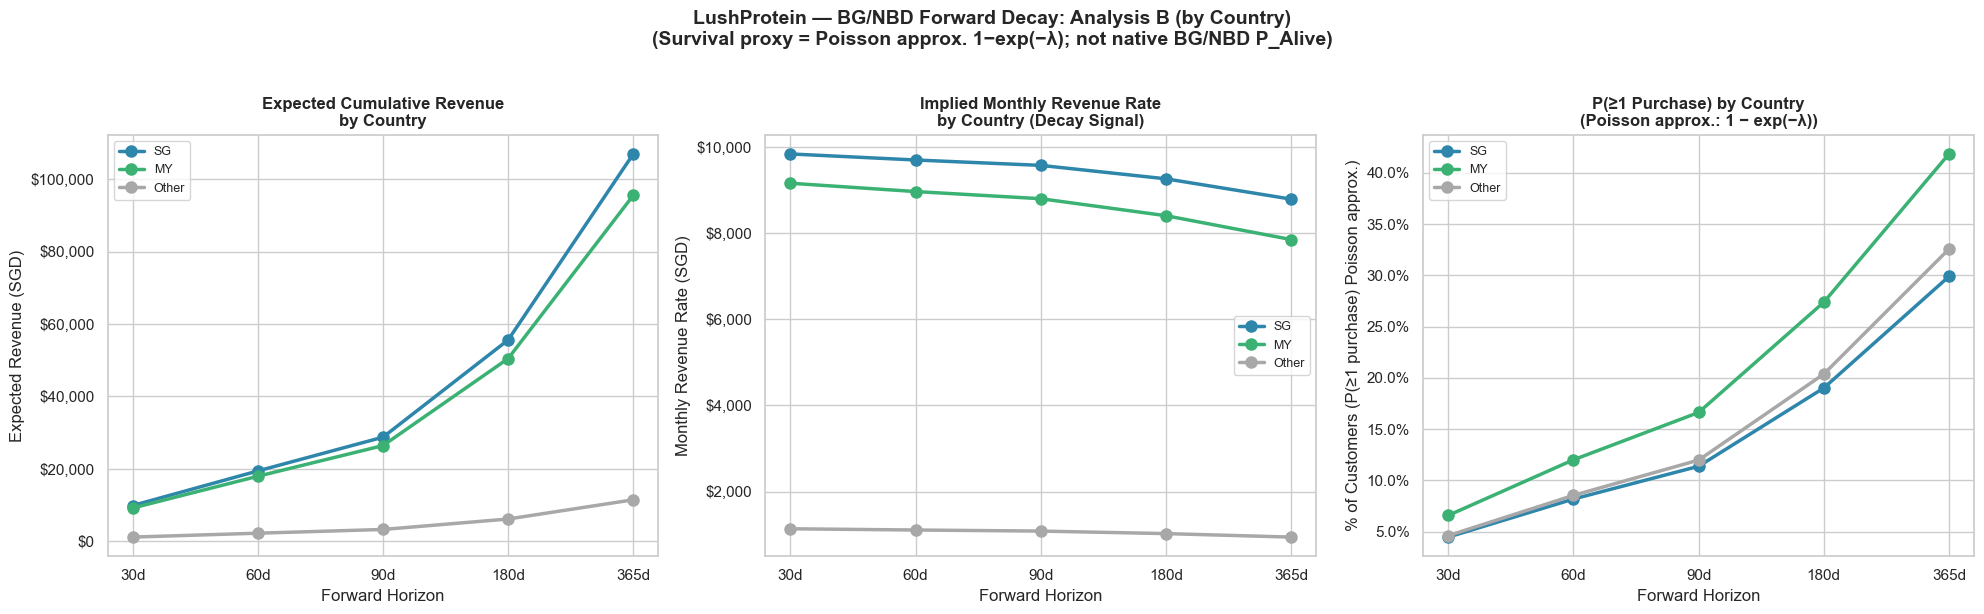

In [28]:
COUNTRY_ORDER = ['SG', 'MY', 'Other']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel 1: Expected cumulative revenue by country ──────────────────────────
ax1 = axes[0]
for ctry, color in COLORS_COUNTRY.items():
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    revenues = [sub[f'exp_revenue_{lbl}'].sum() for lbl in HORIZON_LABELS]
    ax1.plot(HORIZON_LABELS, revenues, marker='o', linewidth=2.5,
             markersize=8, label=ctry, color=color)
ax1.set_title('Expected Cumulative Revenue\nby Country', fontsize=12, fontweight='bold')
ax1.set_xlabel('Forward Horizon')
ax1.set_ylabel('Expected Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)

# ── Panel 2: Monthly revenue run rate by country (decay signal) ──────────────
ax2 = axes[1]
for ctry, color in COLORS_COUNTRY.items():
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    rates = [sub[f'exp_revenue_{lbl}'].sum() / HORIZON_DAYS[lbl] * 30
             for lbl in HORIZON_LABELS]
    ax2.plot(HORIZON_LABELS, rates, marker='o', linewidth=2.5,
             markersize=8, label=ctry, color=color)
ax2.set_title('Implied Monthly Revenue Rate\nby Country (Decay Signal)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Forward Horizon')
ax2.set_ylabel('Monthly Revenue Rate (SGD)')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9)

# ── Panel 3: Survival curve — % customers expected to transact by country ──────
ax3 = axes[2]
for ctry, color in COLORS_COUNTRY.items():
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    pct = [sub[f'p_active_{lbl}'].mean() * 100 for lbl in HORIZON_LABELS]
    ax3.plot(HORIZON_LABELS, pct, marker='o', linewidth=2.5,
             markersize=8, label=ctry, color=color)
ax3.set_title('P(≥1 Purchase) by Country\n(Poisson approx.: 1 − exp(−λ))', fontsize=12, fontweight='bold')
ax3.set_xlabel('Forward Horizon')
ax3.set_ylabel('% of Customers (P(≥1 purchase) Poisson approx.)')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend(fontsize=9)

plt.suptitle('LushProtein — BG/NBD Forward Decay: Analysis B (by Country)\n'
             '(Survival proxy = Poisson approx. 1−exp(−λ); not native BG/NBD P_Alive)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clv_decay_country.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Country decay summary table
print('=== Country Decay Summary ===')
for ctry in COUNTRY_ORDER:
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    rate_30  = sub['exp_revenue_30d'].sum()  # 30-day cumulative total
    rate_365 = sub['exp_revenue_365d'].sum() / 365 * 30
    decay_pct = (rate_30 - rate_365) / rate_30 * 100 if rate_30 > 0 else 0
    print(f'{ctry:10s} (n={len(sub):,}): 30d rate SGD {rate_30:>10,.0f} → '
          f'365d rate SGD {rate_365:>10,.0f}  (decay {decay_pct:.1f}%)')

=== Country Decay Summary ===
SG         (n=2,110): 30d rate SGD      9,847 → 365d rate SGD      8,796  (decay 10.7%)
MY         (n=1,468): 30d rate SGD      9,166 → 365d rate SGD      7,857  (decay 14.3%)
Other      (n=261): 30d rate SGD      1,134 → 365d rate SGD        941  (decay 17.1%)


## Country Decay Summary: Detailed Findings

The per-country breakdown (n=3,839) connects directly back to the Lazada VIP finding from earlier — and unlike Shopee's decay, this one looks like a **genuine signal** rather than a data-maturity artifact.

**Per-customer annual value** (using `cumulative_365d = rate_365 × 365/30`):

| Country | n | Per-Customer Annual Value (SGD) |
|---|---|---|
| MY | 1,468 | **65.08** |
| SG | 2,110 | 50.71 |
| Other | 261 | 43.86 |

**MY has the highest per-customer value despite having ~30% fewer customers than SG** — consistent with MY also having the highest `P(≥1 purchase)` across all horizons (reaching ~42% by 365d vs SG's ~30%).

**Decay rates and absolute contribution** (30-day implied monthly rate → 365-day implied monthly rate):

| Country | Decay % | Absolute Decay (SGD/month) | Share of Total | Per-Customer Decay (SGD) |
|---|---|---|---|---|
| Other | 17.1% | 193 | 7.6% | 0.74 |
| MY | 14.3% | **1,309** | **51.3%** | **0.89** |
| SG | 10.7% | 1,051 | 41.2% | 0.50 |

**MY contributes over half (51.3%) of the total revenue-at-risk (~SGD 2,553/month)** — despite having fewer customers than SG. On a **per-customer basis, MY's decay (SGD 0.89) is ~1.8x SG's (SGD 0.50)**.

**Why this looks like a genuine signal, not a maturity artifact (unlike Shopee)**: the "Lazada Lapsed VIP" customers identified earlier were **predominantly Malaysia-based** — consistent with Lazada itself being a Malaysia-heavy channel, and the ~98 long-tenure "still active" Lazada customers added during population scoping. These customers have **3-6 years of purchase history**, giving BG/NBD ample evidence (unlike Shopee's <8-month-old proven customers). When the model projects declining `exp_purchases_t` for customers with this much history behind them, it reflects **substantial evidence of an actual slowdown** — i.e., **MY's elevated decay rate is likely driven by the same small group of high-AOF, currently-slipping Lazada VIPs validated earlier**, representing a **real retention risk** rather than a statistical artifact.

**Business implication**: this **geographically anchors** the earlier win-back recommendation. The "Lazada Lapsed VIP" outreach isn't just a small abstract segment — it's likely **the single largest driver of MY's disproportionate share of revenue-at-risk** (SGD 1,309/month, more than SG's 1,051 despite MY having 30% fewer customers). A retention campaign targeting these specific high-value MY customers could disproportionately reduce the *total* revenue-at-risk figure, not just MY's portion.

**"Other" (n=261)** has the highest *proportional* decay (17.1%) but the smallest absolute impact (SGD 193/month, 7.6% of total) — low priority given its small scale.

---
## 5. Revenue at Risk Summary

=== Revenue at Risk by Segment ===
(Difference between near-term and long-term monthly revenue run rate)



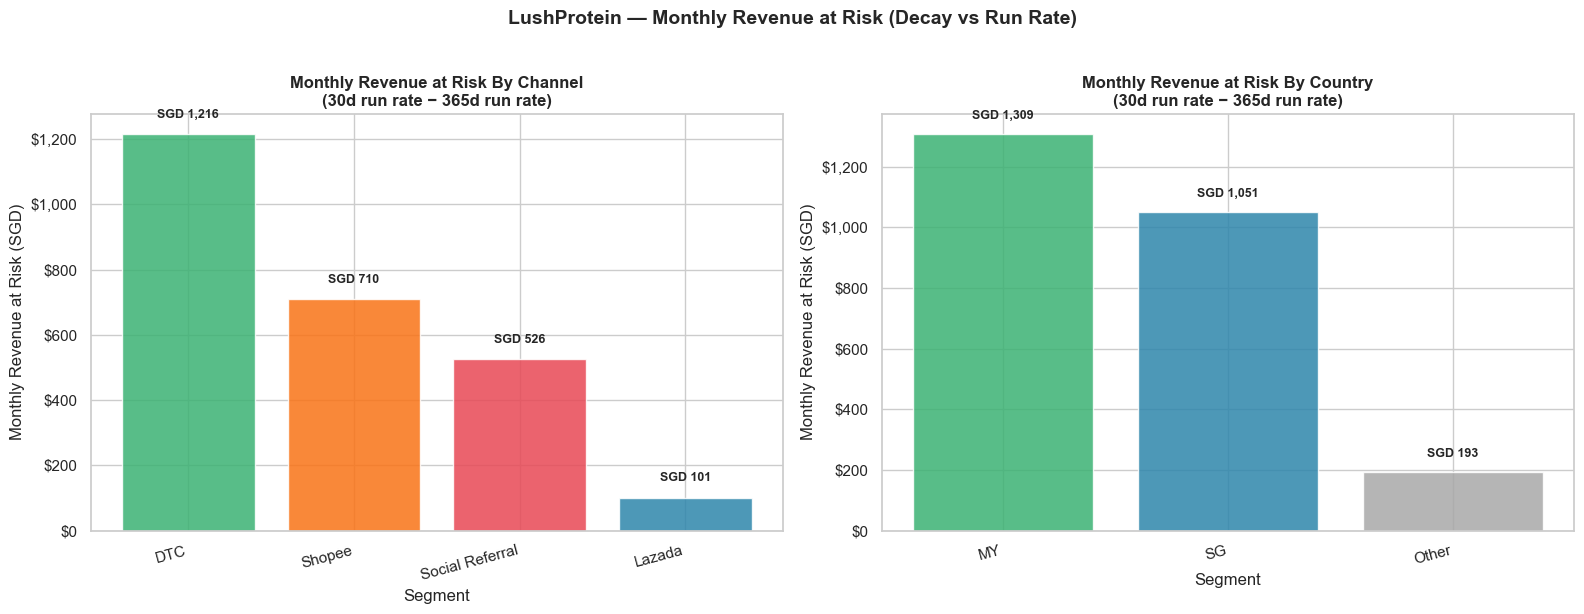

In [32]:
# Revenue at risk = expected 30-day run rate − expected 365-day run rate
# (how much monthly revenue is being 'lost' as the customer base decays)
print('=== Revenue at Risk by Segment ===')
print('(Difference between near-term and long-term monthly revenue run rate)\n')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, groupby, colors, title in [
    (axes[0], 'acquisition_channel', COLORS_CHANNEL, 'By Channel'),
    (axes[1], 'country',              COLORS_COUNTRY,  'By Country'),
]:
    risk_rows = []
    for key, sub in rfm.groupby(groupby):
        rate_30  = sub['exp_revenue_30d'].sum()                  # 30-day cumulative total == 30-day monthly rate
        rate_365 = sub['exp_revenue_365d'].sum() / 365 * 30
        risk = rate_30 - rate_365
        risk_rows.append({'Segment': key, 'Rate_30d': rate_30,
                          'Rate_365d': rate_365, 'Revenue_at_Risk': risk})
    risk_df = pd.DataFrame(risk_rows).sort_values('Revenue_at_Risk', ascending=False)

    bar_colors = [colors.get(s, '#A8A8A8') for s in risk_df['Segment']]
    bars = ax.bar(risk_df['Segment'], risk_df['Revenue_at_Risk'],
                  color=bar_colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, risk_df['Revenue_at_Risk']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 50,
                f'SGD {val:,.0f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Monthly Revenue at Risk {title}\n(30d run rate − 365d run rate)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Segment')
    ax.set_ylabel('Monthly Revenue at Risk (SGD)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.suptitle('LushProtein — Monthly Revenue at Risk (Decay vs Run Rate)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clv_revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions & Recommendations

**Model setup**: BG/NBD and Gamma-Gamma were fit on a carefully-scoped population of **3,839 customers** — derived from 13,885 total customers by excluding data-quality issues (Matrixify/B2B/guest-checkout, n=1,558) and applying a combined acquisition-cohort/recency filter that removes "ancient and dormant" customers (n=6,061, mostly a defunct 2020-2022 Lazada cohort) while retaining both "recent but already at-risk" customers (avoiding survivorship bias) and "long-tenure but still active" customers (avoiding undercounting the Loyal/Active segment).

**Headline figures**: the model projects **~SGD 58,403 in expected revenue over the next 90 days**, with an aggregate **~SGD 2,552/month in "Revenue at Risk"** — the gap between the current near-term pace and the pace the model expects to be sustained over a full year as some currently-active customers churn.

**Segmentation** (`P_Alive` × `AOF`):

| Segment | % of Customers | % of 90d Revenue |
|---|---|---|
| Loyal / Active | 14% | 49% |
| New / Unproven | 72% | 40% |
| At Risk | 9% | 10% |
| Lapsed / Lost | 5% | 1% |

**Prioritized recommendations**:

1. **Personalized win-back for "Lazada Lapsed VIPs"** (validated, n≈6 core individuals within a ~98-customer long-tenure-active cohort, predominantly Malaysia-based). These customers have 3-6 years of purchase history (AOF up to 46, spend up to SGD 6,671) and are the primary driver of MY's outsized revenue-at-risk (SGD 1,309/month, 51% of the total). This is the highest-confidence, most concrete action item from this analysis.

2. **DTC retention programs**, given DTC represents 60% of the customer base and the largest absolute revenue-at-risk (SGD 1,216/month, 48% of the total) — even modest retention improvements here have the largest dollar impact of any channel.

3. **Second-purchase incentives for "New/Unproven"** (72% of customers, 40% of near-term revenue but lowest per-customer value at SGD 8.42). This is the conversion funnel — moving even a fraction of this segment into "Loyal/Active" (SGD 52.76/customer) represents the highest long-run leverage.

4. **Monitor (don't yet act on) Shopee's elevated decay rate** (18.4%, the highest of any channel) — investigation suggests this is likely a "channel maturity" artifact (Shopee has existed only since Aug 2025, giving BG/NBD limited history for its proven customers) rather than a genuine retention issue. Re-evaluate in 6-12 months.

**Key limitations**: (a) absolute revenue figures are sensitive to population composition and should be treated as directional, not precise; (b) Gamma-Gamma's independence assumption is weakly violated (driven by the Lazada VIPs' high AOF/AOV), adding uncertainty to monetary estimates — likely understating value for high-frequency customers; (c) `TARGET_CHANNELS` excludes ~18% of customers (Marketplace, Draft Order, POS, Email) for scoping simplicity, not technical necessity — Marketplace (n=1,189) in particular remains an open question for future work; (d) the `p_active_t` survival proxy used in the decay charts is a different metric from `P_Alive` and shouldn't be read as a projected churn probability.